## Load dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv('../Data/Penguin Species Prediction Dataset.csv')

In [4]:
dataset.head(5)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male


In [5]:
dataset.shape

(1000, 7)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            1000 non-null   object 
 1   island             1000 non-null   object 
 2   culmen_length_mm   990 non-null    float64
 3   culmen_depth_mm    990 non-null    float64
 4   flipper_length_mm  990 non-null    float64
 5   body_mass_g        990 non-null    float64
 6   sex                990 non-null    object 
dtypes: float64(4), object(3)
memory usage: 54.8+ KB


## EDA

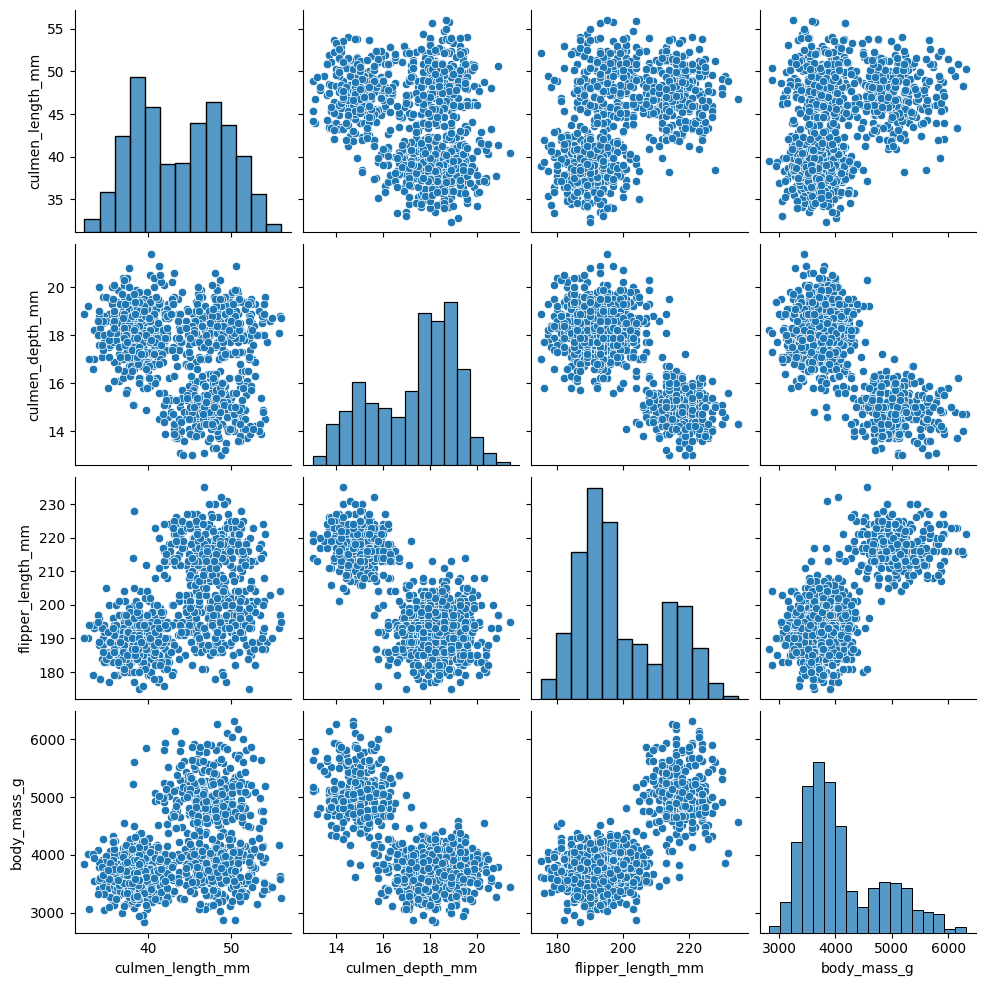

In [ ]:
sns.pairplot(dataset)

In [7]:
dataset.select_dtypes('float64').corr()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,-0.345736,0.501438,0.372168
culmen_depth_mm,-0.345736,1.000000,-0.749143,-0.739795
flipper_length_mm,0.501438,-0.749143,1.000000,0.754717
body_mass_g,0.372168,-0.739795,0.754717,1.000000


In [8]:
dataset.select_dtypes('float64').cov()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,28.195942,-3.255251,35.110554,1390.978683
culmen_depth_mm,-3.255251,3.165044,-17.574744,-930.012021
flipper_length_mm,35.110554,-17.574744,173.492637,7020.162859
body_mass_g,1390.978683,-930.012021,7020.162859,497497.171059


In [9]:
dataset['species'].value_counts()

species
Adelie       461
Gentoo       288
Chinstrap    251
Name: count, dtype: int64

## Data cleaning

In [10]:
dataset.isnull().sum()

species               0
island                0
culmen_length_mm     10
culmen_depth_mm      10
flipper_length_mm    10
body_mass_g          10
sex                  10
dtype: int64

In [11]:
dataset.isnull().sum()/dataset.shape[0]*100

species              0.0
island               0.0
culmen_length_mm     1.0
culmen_depth_mm      1.0
flipper_length_mm    1.0
body_mass_g          1.0
sex                  1.0
dtype: float64

In [12]:
dataset.duplicated().sum()

0

## Train-test split

In [13]:
x=dataset.drop(columns='species')
y= dataset['species']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)


from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
x.columns

Index(['island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex'],
      dtype='object')

## Making Pipelines

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer

In [16]:
numeric_features = x.select_dtypes('float64').columns
categorical_features = x.select_dtypes('object').columns

numeric_pipeline1 = Pipeline([
    ('Impute',SimpleImputer(strategy='mean')),
    ('Scaling',StandardScaler())
])

numeric_pipeline2 = Pipeline([            # Dt,Rf
    ('Impute',SimpleImputer(strategy='mean'))
    ])

numeric_pipeline3 = Pipeline([           # CatBoost
    ('Impute',SimpleImputer(strategy='mean'))
])

# Remove OneHotEncoder from numeric_pipeline1 and numeric_pipeline2.
#These pipelines should only handle imputation and, if needed, scaling for numerical features

In [17]:
categorical_pipeline1 = Pipeline([
    ('Impute',SimpleImputer(strategy='most_frequent')),
    ('Encoding',OneHotEncoder(handle_unknown='ignore'))
])
categorical_pipeline2 = Pipeline([    # Catboost
    ('Impute',SimpleImputer(strategy='most_frequent'))
])

In [18]:
preprocessor_ies = ColumnTransformer([
    ('numerical',numeric_pipeline1,numeric_features),

    ('Categorical',categorical_pipeline1,categorical_features)
])

# No scaling : ----- Decisiom tree ,random forest
preprocessor_ie = ColumnTransformer([
    ('numerical',numeric_pipeline2,numeric_features),

    ('Categorical',categorical_pipeline1,categorical_features)
])

# No scaling & Encoding : -- Catboost
preprocessor_i = ColumnTransformer([
    ('numerical',numeric_pipeline3,numeric_features),

    ('Categorical',categorical_pipeline2,categorical_features)
])

In [19]:
preprocessor_i

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('Impute', SimpleImputer())]),
                                 Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g'],
      dtype='object')),
                                ('Categorical',
                                 Pipeline(steps=[('Impute',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 Index(['island', 'sex'], dtype='object'))])

In [20]:
preprocessor_ies

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('Impute', SimpleImputer()),
                                                 ('Scaling',
                                                  StandardScaler())]),
                                 Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g'],
      dtype='object')),
                                ('Categorical',
                                 Pipeline(steps=[('Impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('Encoding',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['island', 'sex'], dtype='object'))])

In [21]:
preprocessor_ie

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('Impute', SimpleImputer())]),
                                 Index(['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm',
       'body_mass_g'],
      dtype='object')),
                                ('Categorical',
                                 Pipeline(steps=[('Impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('Encoding',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['island', 'sex'], dtype='object'))])

## Baseline model selection

In [22]:
 #         Dummy Classifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(x_train,y_train)
y_pred_dummy = dummy.predict(x_test)
print(accuracy_score(y_test,y_pred_dummy))

0.48


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [24]:
models = {

    'Logistic Regression':Pipeline([
        ('Preprocessor',preprocessor_ies),
        ('Model',LogisticRegression())
    ]),

    'Decision Tree':Pipeline([
        ('Preprocessor',preprocessor_ie),
        ('Model',DecisionTreeClassifier(max_depth=4,random_state=42))
    ]),

    'K-Nearest':Pipeline([
        ('Preprocessor',preprocessor_ies),
        ('Model',KNeighborsClassifier(n_jobs=-1,n_neighbors=5))
    ]),

    'Random Forest':Pipeline([
        ('Preprocessor',preprocessor_ie),
        ('Model',RandomForestClassifier(n_estimators=100))
    ]),

    "Naive_bayes":Pipeline([
        ('Preprocessor',preprocessor_ies),
        ('Model',GaussianNB())
    ]),

}

## Cross-validation

In [25]:
from sklearn.model_selection import StratifiedKFold,cross_validate

In [24]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model_recall_scores = {}

for name,pipeline in models.items():
  scores = cross_validate(
      pipeline,x_train,y_train,
      cv=cv,
      scoring=['accuracy','precision_weighted','recall_weighted','f1_weighted','balanced_accuracy'],
      n_jobs=-1

  )
  model_recall_scores[name] = scores['test_recall_weighted'].mean()

  print(
      name,
       'Accuracy:', round(scores['test_accuracy'].mean(),2),
        'Precision:', round(scores['test_precision_weighted'].mean(),2),
        'Recall:', round(scores['test_recall_weighted'].mean(),2),
        'F1:', round(scores['test_f1_weighted'].mean(),2)
    )


Logistic Regression Accuracy: 0.99 Precision: 0.99 Recall: 0.99 F1: 0.99
Decision Tree Accuracy: 0.98 Precision: 0.98 Recall: 0.98 F1: 0.98
K-Nearest Accuracy: 0.98 Precision: 0.98 Recall: 0.98 F1: 0.98
Random Forest Accuracy: 0.99 Precision: 0.99 Recall: 0.99 F1: 0.99
Naive_bayes Accuracy: 0.72 Precision: 0.86 Recall: 0.72 F1: 0.7


## select best model

                    5-fold CV
                       ↓
          ┌────────────┴────────────┐
          ↓                         ↓
     Random Forest              Logistic
          ↓                         ↓
      Hyperparameter             Hyperparameter
        tuning                     tuning
          ↓                         ↓
       CV again                  CV again
          └────────────┬────────────┘
                       ↓
                 Final candidate
                       ↓
              Untouched test set

In [25]:
sorted_models_by_recall = sorted(model_recall_scores.items(), key=lambda item: item[1], reverse=True)

print("\nTop 2 models based on Recall Score:")
for i, (model_name, recall_score) in enumerate(sorted_models_by_recall[:2]):
    print(f"{i+1}. {model_name}: {recall_score:.2f}")


Top 2 models based on Recall Score:
1. Logistic Regression: 0.99
2. Random Forest: 0.99


## Hyper Parameter tunning

In [26]:
from sklearn.model_selection import RandomizedSearchCV

In [27]:
rf_params = {
    'Model__n_estimators': [200, 300, 500],
    'Model__max_depth': [None, 10, 20, 30],
    'Model__min_samples_split': [2, 5, 10],
    'Model__min_samples_leaf': [1, 2, 4],
    'Model__max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    models['Random Forest'],
    param_distributions=rf_params,
    n_iter=20,
    scoring='f1_weighted',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(x_train, y_train)

print(rf_search.best_params_)
print(rf_search.best_score_)

{'Model__n_estimators': 200, 'Model__min_samples_split': 10, 'Model__min_samples_leaf': 4, 'Model__max_features': 'log2', 'Model__max_depth': 30}
0.99001739770068


In [28]:
lr_params = {
    'Model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'Model__solver': ['newton-cg', 'lbfgs', 'liblinear'],
    'Model__penalty': ['l2']
}

lr_search = RandomizedSearchCV(
    models['Logistic Regression'],
    param_distributions=lr_params,
    n_iter=20,
    scoring='f1_weighted',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

lr_search.fit(x_train, y_train)

print(lr_search.best_params_)
print(lr_search.best_score_)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


{'Model__solver': 'newton-cg', 'Model__penalty': 'l2', 'Model__C': 10}
0.991214641085653


## Final evaluation on your test set

In [29]:
best_model_1 = rf_search.best_estimator_

best_model_1.fit(x_train, y_train)

test_score = best_model_1.score(x_test, y_test)

print("Final test accuracy:", test_score)

Final test accuracy: 1.0


In [30]:
# or a proper classification evaluation
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_model_1.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[96  0  0]
 [ 0 52  0]
 [ 0  0 52]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00        52
           2       1.00      1.00      1.00        52

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



### For second best model

In [31]:
best_model_2 = lr_search.best_estimator_

best_model_2.fit(x_train, y_train)

test_score = best_model_2.score(x_test, y_test)

print("Final test accuracy:", test_score)

Final test accuracy: 1.0


In [32]:
# or a proper classification evaluation
from sklearn.metrics import classification_report, confusion_matrix

y_pred = best_model_2.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# At this point, you have your final trained pipeline

[[96  0  0]
 [ 0 52  0]
 [ 0  0 52]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00        52
           2       1.00      1.00      1.00        52

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [33]:
y_pred

array([0, 2, 1, 0, 2, 2, 1, 2, 0, 1, 2, 2, 1, 0, 0, 0, 2, 0, 0, 0, 2, 1,
       0, 0, 1, 2, 1, 1, 0, 2, 1, 2, 0, 2, 0, 2, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 2, 1, 0, 1, 0, 0, 1, 2, 2, 1, 0, 0, 0, 1,
       1, 0, 2, 1, 2, 0, 0, 0, 2, 1, 1, 0, 0, 0, 2, 0, 1, 2, 0, 1, 2, 0,
       0, 1, 1, 1, 2, 1, 0, 0, 0, 2, 0, 0, 2, 2, 0, 2, 0, 0, 2, 2, 0, 2,
       0, 0, 1, 1, 2, 1, 0, 1, 2, 0, 2, 1, 0, 1, 0, 1, 0, 2, 0, 2, 0, 1,
       2, 0, 2, 2, 2, 0, 2, 0, 0, 2, 0, 0, 0, 1, 2, 0, 0, 2, 0, 0, 0, 0,
       1, 2, 0, 1, 0, 2, 1, 2, 1, 0, 1, 0, 1, 0, 2, 0, 1, 1, 0, 2, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 2, 1, 0, 1, 1, 2, 1, 0, 2, 0, 2, 0, 0,
       0, 0])

## Saving model

In [34]:
import joblib

joblib.dump(best_model_2,'penguin_model.pkl')
joblib.dump(le, "label_encoder.pkl")
#If you're deploying the model, don't only save the model. Save the fitted LabelEncoder as well.

['label_encoder.pkl']

In [ ]:
#Save the entire pipeline
joblib.dump(best_model, 'model_pipeline.pkl')